# Modelo com Rebalanceamento e Custos de Transação 

In [1]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
import pandas as pd

# Carrega os dados fundamentalistas dos anos 2021, 2022, 2023, 2024 e 2025
df_2021 = pd.read_excel('../../base_dados/base-dados-pesquisa/2021/ibovespa_magic_formula_2021.xlsx')
df_2022 = pd.read_excel('../../base_dados/base-dados-pesquisa/2022/ibovespa_magic_formula_2022.xlsx')
df_2023 = pd.read_excel('../../base_dados/base-dados-pesquisa/2023/ibovespa_magic_formula_2023.xlsx')
df_2024 = pd.read_excel('../../base_dados/base-dados-pesquisa/2024/ibovespa_magic_formula_2024.xlsx')
df_2025 = pd.read_excel('../../base_dados/base-dados-pesquisa/2025/ibovespa_magic_formula_2025.xlsx')

# Identifica empresas que estão em ２０２５ (filtro maior)
empresas_2025 = df_2025['ativo'].unique()

# Filtra 2021 pelas empresas de 2025
df_2021_filtrado = df_2021[df_2021['ativo'].isin(empresas_2025)]
# Filtra 2022 pelas empresas de 2025
df_2022_filtrado = df_2022[df_2022['ativo'].isin(empresas_2025)]
# Filtra 2023 pelas empresas de 2025
df_2023_filtrado = df_2023[df_2023['ativo'].isin(empresas_2025)]
# Filtra 2024 pelas empresas de 2025
df_2024_filtrado = df_2024[df_2024['ativo'].isin(empresas_2025)]

# Concatena um embaixo do outro
df_combinado = pd.concat([df_2021_filtrado, df_2022_filtrado, df_2023_filtrado, df_2024_filtrado, df_2025], ignore_index=True)

# Ordena por empresa e data (opcional, mas fica mais organizado)
df_combinado = df_combinado.sort_values(['ativo', 'dt_refer']).reset_index(drop=True)

# Salva
df_combinado.to_excel('../../base_dados/base-dados-pesquisa/juncao-anos/df_anos.xlsx', index=False)

print(f"✓ Total: {len(df_combinado)} linhas")
print(f"✓ Empresas: {df_combinado['ativo'].nunique()}")
print(f"✓ Datas: {sorted(df_combinado['dt_refer'].unique())}")

✓ Total: 947 linhas
✓ Empresas: 64
✓ Datas: ['2021-03-31', '2021-06-30', '2021-09-30', '2022-03-31', '2022-06-30', '2022-09-30', '2023-03-31', '2023-06-30', '2023-09-30', '2024-03-31', '2024-06-30', '2024-09-30', '2025-03-31', '2025-06-30', '2025-09-30']


In [3]:
basedados_ativos = Path('../../base_dados/retornos_ativos_2023_2026.csv') 
basedados_ibov = Path('../../base_dados/retorno_ibov_2023_2026.csv') 

path_df_mf = Path('../../base_dados/base-dados-pesquisa/juncao-anos/df_anos.xlsx') 

df_ativos=pd.read_csv(basedados_ativos).set_index(['Date']).fillna(0)

df_ibov=pd.read_csv(basedados_ibov).set_index(['Date']).dropna()

df_mf=pd.read_excel(path_df_mf).set_index(['ativo'])

In [4]:
## Existem missing values, se caso o modelo nao funcionar, é por isso
df_mf

,dt_refer,caixa,ativo_total,divida_cp,divida_lp,pl,receita,ebit,lucro,ticker,...,div_ebitda,ROA,giro_ativo,alavancagem,preco,cnpj_norm,acoes_circ,valor_mercado,EV,earnings_yield
ativo,,,,,,,,,,,,,,,,,,,,,
ALLOS S.A.,2021-03-31,2289.0,8288173.0,177316.0,1380764.0,6589879,36409.0,59716,41877.0,ALOS3,...,26.091500,0.005053,0.004393,0.187988,21.220152,5.878397e+12,264896090,5.621135e+09,5.622691e+09,0.000011
ALLOS S.A.,2021-06-30,646.0,8247362.0,371700.0,1143478.0,6631102,35535.0,75256,56705.0,ALOS3,...,20.133650,0.006876,0.004309,0.183717,22.581907,5.878397e+12,265129187,5.987123e+09,5.988637e+09,0.000013
ALLOS S.A.,2021-09-30,1551.0,8559210.0,323624.0,1438791.0,6693813,42864.0,75477,60584.0,ALOS3,...,23.350358,0.007078,0.005008,0.205909,17.667381,5.878397e+12,265129187,4.684138e+09,4.685899e+09,0.000016
ALLOS S.A.,2022-03-31,NaN,NaN,NaN,NaN,6826904,NaN,102890,NaN,ALOS3,...,0.000000,0.006128,0.005139,0.000000,17.993984,NaN,265149193,4.771090e+09,4.771083e+09,0.000022
ALLOS S.A.,2022-06-30,NaN,NaN,NaN,NaN,6708840,NaN,75958,NaN,ALOS3,...,0.000000,0.002677,0.004993,0.000000,12.687920,NaN,265728995,3.371548e+09,3.371539e+09,0.000023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YDUQS PARTICIPACOES S.A.,2024-06-30,NaN,NaN,NaN,NaN,3142667,NaN,150087,NaN,YDUQ3,...,23.751611,0.003617,0.000000,0.529840,9.549833,NaN,292360,2.791989e+06,6.352441e+06,0.023627
YDUQS PARTICIPACOES S.A.,2024-09-30,NaN,NaN,NaN,NaN,3217697,NaN,243395,NaN,YDUQ3,...,14.716120,0.022276,0.000000,0.525230,8.504030,NaN,284871,2.422552e+06,6.001520e+06,0.040556
YDUQS PARTICIPACOES S.A.,2025-03-31,NaN,NaN,NaN,NaN,3118062,NaN,295834,NaN,YDUQ3,...,18.151345,0.013082,NaN,NaN,10.586462,NaN,262093,2.774638e+06,7.557992e+06,0.039142


In [5]:
# df_mf = df_mf.filter(items=['ticker','dt_refer','earnings_yield','ROIC'])
df_mf['ticker'] = df_mf['ticker']+".SA"
df_mf['earnings_yield'].fillna(0, inplace=True)
df_mf_2021 = df_mf[df_mf['dt_refer'].str.contains('2021')]
df_mf_2022 = df_mf[df_mf['dt_refer'].str.contains('2022')]
df_mf_2023 = df_mf[df_mf['dt_refer'].str.contains('2023')]
df_mf_2024 = df_mf[df_mf['dt_refer'].str.contains('2024')]
df_mf_2025 = df_mf[df_mf['dt_refer'].str.contains('2025')]


C:\Users\joaon\AppData\Local\Temp\ipykernel_18576\3952470534.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mf['earnings_yield'].fillna(0, inplace=True)


In [6]:
df_mf.fillna(-0.1, inplace=True)    

In [7]:


dados_retorno_2023_2025 = df_ativos.query('Date >= "2023-01-03" and Date < "2025-12-31"')
dados_retorno_2026 = df_ativos.query('Date > "2025-12-31"')

dados_retorno_2023_2025 = dados_retorno_2023_2025.filter(items=df_mf['ticker'].unique())
dados_retorno_2026 = dados_retorno_2026.filter(items=df_mf['ticker'].unique())
print(dados_retorno_2023_2025.shape)
print(dados_retorno_2026.shape)



## IBOV

dados_retorno_ibov_2023_2025 = df_ibov.query('Date >= "2023-01-01" and Date < "2025-12-31"')
dados_retorno_ibov_2023_2025 = dados_retorno_ibov_2023_2025.filter(items=['IBOV'])

print(dados_retorno_ibov_2023_2025.shape)

dados_retorno_ibov_2026 = df_ibov.query('Date > "2025-12-31"')
dados_retorno_ibov_2026 = dados_retorno_ibov_2026.filter(items=['IBOV'])
print(dados_retorno_ibov_2026.shape)



(748, 64)
(102, 64)
(748, 1)
(102, 1)


In [23]:
vb_cardinalidade_max = 40
vb_cardinalidade_min = 10
vb_peso_maximo = 0.15
vb_peso_minimo = 0.05
vb_theta = 2

# Modelo com dados fundamentalistas

In [9]:
scores = []

for ticker in df_mf['ticker'].unique():
    df_ticker = df_mf[df_mf['ticker'] == ticker]
    
    score_total = (0.5 * df_ticker['earnings_yield'] + 0.5 * df_ticker['ROIC']).sum()
    
    scores.append({
        'ticker': ticker,
        'score_fundamentalista': score_total,
        'n_periodos': len(df_ticker)
    })

df_scores = pd.DataFrame(scores).sort_values('score_fundamentalista', ascending=False)
dfscores = df_scores.set_index('ticker').drop(columns=['n_periodos'])
print(dfscores)

          score_fundamentalista
ticker                         
VALE3.SA               1.463047
CMIN3.SA               1.294401
CMIG4.SA               1.179298
BRKM5.SA               0.886232
ITSA4.SA               0.752310
...                         ...
SMFT3.SA               0.079282
EMBJ3.SA               0.056848
COGN3.SA               0.027146
HAPV3.SA               0.021998
CPFE3.SA             -50.557713

[64 rows x 1 columns]


In [24]:
# ------ CRIAÇÃO DO MODELO
model = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model.nome_ativos = pyo.Set(initialize = dados_retorno_2023_2025.columns)
model.ativos = pyo.RangeSet(0, len(dados_retorno_2023_2025.columns)-1)
model.dias = pyo.RangeSet(0, len(dados_retorno_2023_2025)-1)
model.retornos_ativos = pyo.Param(model.dias, model.ativos, initialize=lambda model,dia, ativo: dados_retorno_2023_2025.iloc[dia, ativo])    
# model.retornos_ibov = pyo.Param(model.dias, initialize=lambda model,dia: dados_retorno_2024['IBOV'].iloc[dia])
model.theta = pyo.Param(initialize=vb_theta)

#Score do ano anterior utilizado pra frente
model.score = pyo.Param(model.ativos, initialize=lambda model, ativo: dfscores.iloc[ativo, 0])

model.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model.x = pyo.Var(model.ativos, bounds=(0,1))
model.y = pyo.Var(model.ativos, within=pyo.Binary)

# # Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
# model.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

# Definindo função objetivo
# a ideia na primeira parte é reduzir o erro quadrático
def func_objetivo_1(model):

    retorno_esperado = sum((sum(model.retornos_ativos[dia, a] * model.x[a] for a in model.ativos)) for dia in model.dias) 

    score_total = model.theta * sum(model.x[a] * model.score[a]  for a in model.ativos)

    # custo_cardinalidade = model.card_valor * 5
    
    return retorno_esperado + score_total 

model.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model.x[a] <= model.y[a]
model.const_restr_vinculo_x_y = pyo.Constraint(model.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model.x[a] <= model.peso_maximo

model.const_peso_maximo = pyo.Constraint(model.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model.x[a] >= model.peso_minimo * model.y[a]  # se y=1, então x >= 0.05
model.const_peso_minimo = pyo.Constraint(model.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model.x[a] for a in model.ativos) == 1
model.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model.y[a] for a in model.ativos
        ) <= model.cardinalidade_valor_max
model.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model.y[a] for a in model.ativos
        ) >= model.cardinalidade_valor_min
model.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpeuh7vo99.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp4v72fx8_.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp4v72fx8_.pyomo.lp
Objective sense      : Maximize
Variables            :     128  [Box: 64,  Binary: 64]
Objective nonzeros   :      64
Linear constraints   :     195  [Less: 193,  Greater: 1,  Equal: 1]
  Nonzeros           :     512
  RHS nonzeros       :      67

Variables            : Min LB: 0.000000         Max UB: 1.00000

## MOSTRANDO RESULTADO DA 1 PRIMEIRA PARTE

In [25]:
lista_grande = []
for numero in range(len(dados_retorno_2023_2025.columns)):
    peso_ativo = pyo.value(model.x[numero])
    ativado = pyo.value(model.y[numero])
    
    lista = [peso_ativo, ativado]
    lista_grande.append(lista)
print(lista_grande)
print(vb_cardinalidade_min)
print(vb_cardinalidade_max)
# print('cardinalidade escolhida: ',pyo.value(model.card_valor))

final = pd.DataFrame(lista_grande, columns=["peso_ativo","ativado"], index=dados_retorno_2023_2025.columns)
print(len(final[final['ativado']!=0]))
print(final[final['ativado']!=0])

[[0.15, 1.0], [0.15, 1.0], [0.04999999999999993, 1.0], [0.15, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.15, 1.0], [0.0, 0.0], [0.0, 0.0], [0.05, 1.0], [0.05, 1.0], [0.15000000000000002, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.05, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.05, 1.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, 0.0], [0.0, 0.0]]
10
40
10
          peso_ativo  ativado
ALOS3.SA        0.15      1.0
ABEV3.SA        0.15      1.0
AURE3.SA        0.05      1.0
AXIA6.SA        0.15      1.0
CEAB3.SA        

          peso_ativo  ativado
ALOS3.SA        0.15      1.0
ABEV3.SA        0.15      1.0
AURE3.SA        0.05      1.0
AXIA6.SA        0.15      1.0
CEAB3.SA        0.15      1.0
CPLE3.SA        0.05      1.0
SBSP3.SA        0.05      1.0
CSMG3.SA        0.15      1.0
DIRR3.SA        0.05      1.0
POMO4.SA        0.05      1.0
291.89972209644975
151.4674362638209
Comportamento da carteira em de 2023 - 2025


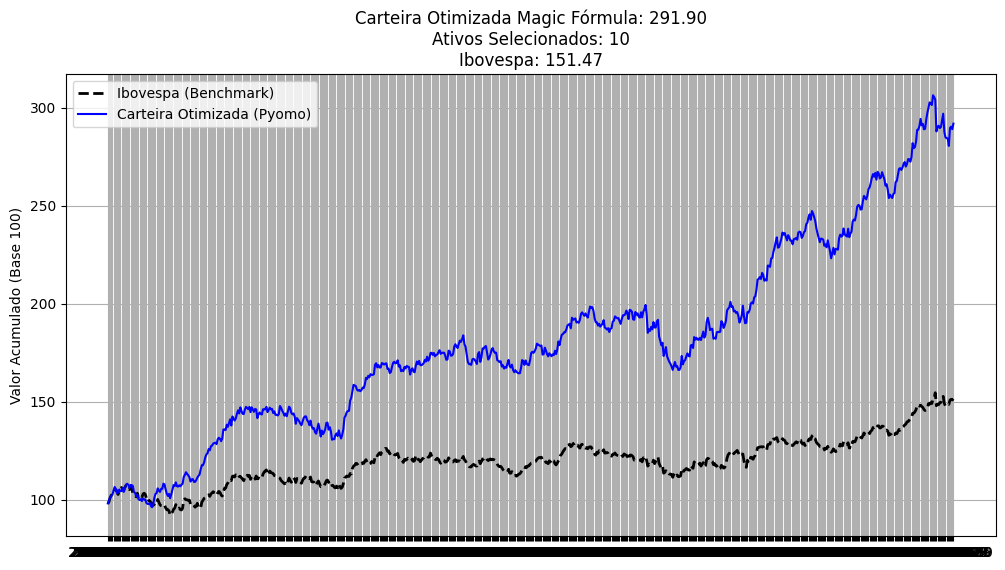

Comportamento da carteira em 2026


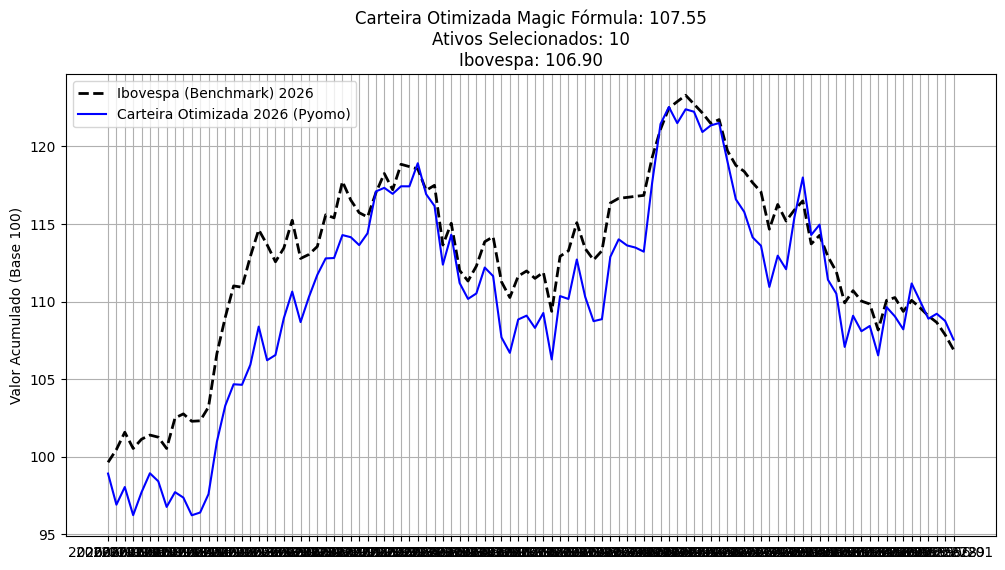

In [26]:
df_final = final[final['ativado']!=0]
print(df_final.head(30))
ativos_selecionados = df_final.index
retornos_carteira= dados_retorno_2023_2025[ativos_selecionados]

carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada




# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100
# acum_equi = (carteira_equi).cumprod() * 100
# acum_ibov = (1 + retornos_ibov_primeira_metade['IBOV']).cumprod() * 100
acum_ibov = (1 + dados_retorno_ibov_2023_2025).cumprod() * 100

print(acum_otimizado.iloc[-1])
# print(acum_equi.iloc[-1])
print(acum_ibov['IBOV'].iloc[-1])

print(("="*80))
print("Comportamento da carteira em de 2023 - 2025")
print(("="*80))

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada Magic Fórmula: {acum_otimizado.iloc[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nIbovespa: {acum_ibov['IBOV'].iloc[-1]:.2f}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()


print(("="*80))
print("Comportamento da carteira em 2026")
print(("="*80))

retornos_carteira_2026 = dados_retorno_2026[ativos_selecionados]
carteira_otimizada_2026 = (retornos_carteira_2026*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada_2026 = 1 + carteira_otimizada_2026
acum_otimizado_2026 = (carteira_otimizada_2026).cumprod() * 100

acum_ibov_2026 = (1 + dados_retorno_ibov_2026).cumprod() * 100


# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov_2026, label='Ibovespa (Benchmark) 2026', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado_2026, label='Carteira Otimizada 2026 (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada Magic Fórmula: {acum_otimizado_2026.iloc[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados)}\nIbovespa: {acum_ibov_2026['IBOV'].iloc[-1]:.2f}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()




### ==========================================
### Usar Pietroski 
### ==========================================

In [13]:
df_mf.replace([np.inf, -np.inf], np.nan, inplace=True)
df_mf.fillna(-0.1, inplace=True)

In [44]:
scores_pietroski = []
dicionarios_scores = []

for ticker in df_mf['ticker'].unique():
    df_ticker = df_mf[df_mf['ticker'] == ticker]
    
    score_total_pietroski = (0.25*df_ticker['ROA']+0.25*df_ticker['margem_liq'] + 0.25*df_ticker['giro_ativo'] + 0.25*df_ticker['alavancagem']).sum()
    score_dic = {
        'ticker': ticker,
        'ROA': df_ticker['ROA'],
        'margem_liq': df_ticker['margem_liq'],
        'giro_ativo': df_ticker['giro_ativo'],
        'alavancagem': df_ticker['alavancagem'],
        
    }
    scores_pietroski.append({
        'ticker': ticker,
        'score_fundamentalista': score_total_pietroski,
        'n_periodos': len(df_ticker)
    })
    dicionarios_scores.append(score_dic)


df_scores_pietroski = pd.DataFrame(scores_pietroski).sort_values('score_fundamentalista', ascending=False)
dfscores_pietroski = df_scores_pietroski.set_index('ticker').drop(columns=['n_periodos'])
print(dfscores_pietroski)
# print(dicionarios_scores[16]['margem_liq'])

           score_fundamentalista
ticker                          
CPFE3.SA           153808.273579
CMIG4.SA             7762.987854
CYRE4.SA              239.273373
AXIA6.SA               75.131512
MOTV3.SA               50.340195
...                          ...
SMFT3.SA                0.148209
CPLE3.SA                0.082775
HAPV3.SA               -0.047324
AURE3.SA               -0.352021
IGTI11.SA          -18769.487776

[64 rows x 1 columns]


### CONTINUAR, falta modelar o pietroski com dados de 21 ate 25, plotar no grafico com ibov da epoca.
### e depois plotar com os dados de 2026, comparar com o modelo otimizado e com o ibov.

In [27]:


# ------ CRIAÇÃO DO MODELO
model_pietroski_1 = pyo.ConcreteModel()

#variavel x para peso, y para cardinalidade

#--------------------
model_pietroski_1.nome_ativos = pyo.Set(initialize = dados_retorno_2023_2025.columns)
model_pietroski_1.ativos = pyo.RangeSet(0, len(dados_retorno_2023_2025.columns)-1)
model_pietroski_1.dias = pyo.RangeSet(0, len(dados_retorno_2023_2025)-1)
model_pietroski_1.retornos_ativos = pyo.Param(model_pietroski_1.dias, model_pietroski_1.ativos, initialize=lambda model,dia, ativo: dados_retorno_2023_2025.iloc[dia, ativo])    
# model_pietroski_1.retornos_ibov = pyo.Param(model_pietroski_1.dias, initialize=lambda model,dia: dados_retorno_2023_2025['IBOV'].iloc[dia])
model_pietroski_1.theta = pyo.Param(initialize=vb_theta)

#Score do ano anterior utilizado pra frente
model_pietroski_1.score = pyo.Param(model_pietroski_1.ativos, initialize=lambda model, ativo: dfscores_pietroski.iloc[ativo, 0])

model_pietroski_1.cardinalidade_valor_max = pyo.Param(initialize=vb_cardinalidade_max)
model_pietroski_1.cardinalidade_valor_min = pyo.Param(initialize=vb_cardinalidade_min)
model_pietroski_1.peso_maximo = pyo.Param(initialize=vb_peso_maximo)
model_pietroski_1.peso_minimo = pyo.Param(initialize=vb_peso_minimo)

model_pietroski_1.x = pyo.Var(model_pietroski_1.ativos, bounds=(0,1))
model_pietroski_1.y = pyo.Var(model_pietroski_1.ativos, within=pyo.Binary)

# # Teste, tentar fazer o modelo descobrir melhor quantidade de ativos na carteira.
# model_pietroski_1.card_valor = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(vb_cardinalidade_min, vb_cardinalidade_max))

    # Definindo função objetivo
# a ideia na primeira parte é reduzir o erro quadrático
def func_objetivo_1(model):

    retorno_esperado = sum((sum(model_pietroski_1.retornos_ativos[dia, a] * model_pietroski_1.x[a] for a in model_pietroski_1.ativos)) for dia in model_pietroski_1.dias) 

    score_total = model_pietroski_1.theta * sum(model_pietroski_1.x[a] * model_pietroski_1.score[a]  for a in model_pietroski_1.ativos)

    # custo_cardinalidade = model_pietroski_1.card_valor * 5
    
    return retorno_esperado + score_total 

model_pietroski_1.obj1 = pyo.Objective(rule=func_objetivo_1, sense=pyo.maximize)

print('-----Model COnstruído-----')


#REstricao 1 x só ativa se y = 1
def restr_vinculo_x_y(model, a):
    return model_pietroski_1.x[a] <= model_pietroski_1.y[a]
model_pietroski_1.const_restr_vinculo_x_y = pyo.Constraint(model_pietroski_1.ativos, rule=restr_vinculo_x_y)

#peso maximo por acao
def rule_peso_maximo(model, a):
    # return model.x[a] <= 1/model.cardinalidade_valor
    return model_pietroski_1.x[a] <= model_pietroski_1.peso_maximo

model_pietroski_1.const_peso_maximo = pyo.Constraint(model_pietroski_1.ativos, rule=rule_peso_maximo)

#peso minimo por acao
def rule_peso_minimo(model, a):
    return model_pietroski_1.x[a] >= model_pietroski_1.peso_minimo * model_pietroski_1.y[a]  # se y=1, então x >= 0.05
model_pietroski_1.const_peso_minimo = pyo.Constraint(model_pietroski_1.ativos, rule=rule_peso_minimo)

#Restrição 2 soma peso 1
def soma_peso_1(model):
    return sum(model_pietroski_1.x[a] for a in model_pietroski_1.ativos) == 1
model_pietroski_1.const_soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

# Restrição 3 de cardinalidade, quantidade de ativos no total
def cardinalidade_max(model):
    return sum(
        model_pietroski_1.y[a] for a in model_pietroski_1.ativos
        ) <= model_pietroski_1.cardinalidade_valor_max
model_pietroski_1.const_cardinalidade_total_max = pyo.Constraint(rule=cardinalidade_max)

def cardinalidade_min(model):
    return sum(
        model_pietroski_1.y[a] for a in model_pietroski_1.ativos
        ) >= model_pietroski_1.cardinalidade_valor_min
model_pietroski_1.const_cardinalidade_total_min = pyo.Constraint(rule=cardinalidade_min)




opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
# opt.options['TimeLimit'] = 60
resultado = opt.solve(model_pietroski_1, tee=True)
print("-------FIM----------")

-----Model COnstruído-----

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpgpb1bkp6.cplex.log' open.
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmp3dpk7lag.pyomo.lp' read.
Read time = 0.00 sec. (0.02 ticks)
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmp3dpk7lag.pyomo.lp
Objective sense      : Maximize
Variables            :     128  [Box: 64,  Binary: 64]
Objective nonzeros   :      64
Linear constraints   :     195  [Less: 193,  Greater: 1,  Equal: 1]
  Nonzeros           :     512
  RHS nonzeros       :      67

Variables            : Min LB: 0.000000         Max UB: 1.00000

In [28]:
lista_grande_pietroski_1 = []
for numero in range(len(dados_retorno_2023_2025.columns)):
    peso_ativo = pyo.value(model_pietroski_1.x[numero])
    ativado = pyo.value(model_pietroski_1.y[numero])
    
    lista_pietroski_1 = [peso_ativo, ativado]
    lista_grande_pietroski_1.append(lista_pietroski_1)
print(lista_grande_pietroski_1)
print(vb_cardinalidade_min)
print(vb_cardinalidade_max)
# print('cardinalidade escolhida: ',pyo.value(model_pietroski_1.card_valor))

final_pietroski_1 = pd.DataFrame(lista_grande_pietroski_1, columns=["peso_ativo","ativado"], index=dados_retorno_2023_2025.columns)
print(len(final_pietroski_1[final_pietroski_1['ativado']!=0]))
print(final_pietroski_1[final_pietroski_1['ativado']!=0])

[[0.15, 1.0], [0.15, 1.0], [0.15, 1.0], [0.15, 1.0], [0.15, 1.0], [0.049999999999999906, 1.0], [0.05, 1.0], [0.05, 1.0], [0.0, 0.0], [0.05, 1.0], [0.05, 1.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0], [0.0, -0.0]]
10
40
10
          peso_ativo  ativado
ALOS3.SA        0.15      1.0
ABEV3.SA        0.15      1.0
AURE3.SA        0.15      1.0
AXIA6.SA        0.15   

          peso_ativo  ativado
ALOS3.SA        0.15      1.0
ABEV3.SA        0.15      1.0
AURE3.SA        0.15      1.0
AXIA6.SA        0.15      1.0
AZZA3.SA        0.15      1.0
B3SA3.SA        0.05      1.0
BRKM5.SA        0.05      1.0
CEAB3.SA        0.05      1.0
CMIG4.SA        0.05      1.0
CPLE3.SA        0.05      1.0
138.30195623875127
151.4674362638209
Comportamento da carteira em de 2023 - 2025


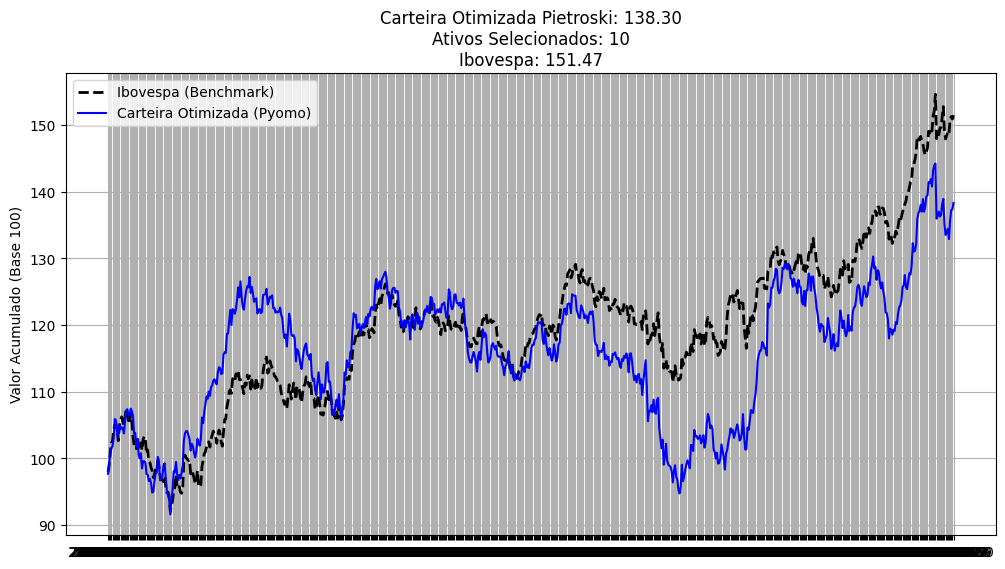

Comportamento da carteira em 2026


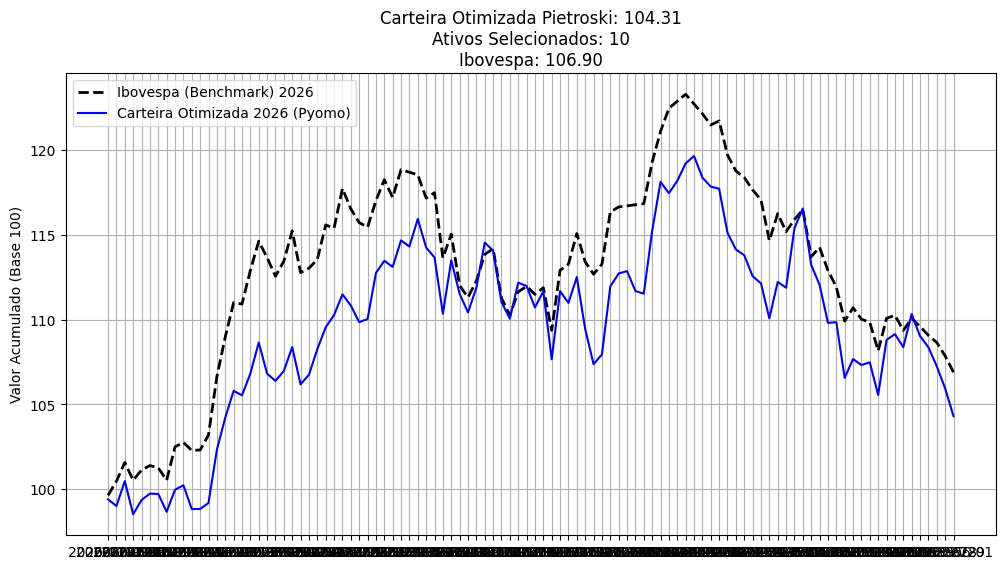

In [29]:
df_final_pietroski_1 = final_pietroski_1[final_pietroski_1['ativado']!=0]
print(df_final_pietroski_1.head(30))
ativos_selecionados_pietroski_1 = df_final_pietroski_1.index
retornos_carteira_ativos_selecionados_pietroski_1= dados_retorno_2023_2025[ativos_selecionados_pietroski_1]

carteira_otimizada_pietroski_1 = (retornos_carteira_ativos_selecionados_pietroski_1*df_final_pietroski_1['peso_ativo']).sum(axis=1)
carteira_otimizada_pietroski_1 = 1 + carteira_otimizada_pietroski_1




# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado_pietroski_1 = (carteira_otimizada_pietroski_1).cumprod() * 100
# acum_equi = (carteira_equi).cumprod() * 100
# acum_ibov = (1 + retornos_ibov_primeira_metade['IBOV']).cumprod() * 100
acum_ibov = (1 + dados_retorno_ibov_2023_2025).cumprod() * 100

print(acum_otimizado_pietroski_1.iloc[-1])
# print(acum_equi.iloc[-1])
print(acum_ibov['IBOV'].iloc[-1])

print(("="*80))
print("Comportamento da carteira em de 2023 - 2025")
print(("="*80))

# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov, label='Ibovespa (Benchmark)', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado_pietroski_1, label='Carteira Otimizada (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada Pietroski: {acum_otimizado_pietroski_1.iloc[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados_pietroski_1)}\nIbovespa: {acum_ibov['IBOV'].iloc[-1]:.2f}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()


print(("="*80))
print("Comportamento da carteira em 2026")
print(("="*80))

retornos_carteira_2026__pietroski_1 = dados_retorno_2026[ativos_selecionados_pietroski_1]
carteira_otimizada_2026_pietroski_1 = (retornos_carteira_2026__pietroski_1*df_final_pietroski_1['peso_ativo']).sum(axis=1)
carteira_otimizada_2026_pietroski_1 = 1 + carteira_otimizada_2026_pietroski_1
acum_otimizado_2026_pietroski_1 = (carteira_otimizada_2026_pietroski_1).cumprod() * 100

acum_ibov_2026 = (1 + dados_retorno_ibov_2026).cumprod() * 100


# 4. Plotar o Gráfico
plt.figure(figsize=(12, 6))
plt.plot(acum_ibov_2026, label='Ibovespa (Benchmark) 2026', color='black', linewidth=2, linestyle='--')
plt.plot(acum_otimizado_2026_pietroski_1, label='Carteira Otimizada 2026 (Pyomo)', color='blue')
# plt.plot(acum_equi, label='Carteira Equiponderada', color='red', alpha=0.5)

texto = f"Carteira Otimizada Pietroski: {acum_otimizado_2026_pietroski_1.iloc[-1]:.2f}\nAtivos Selecionados: {len(ativos_selecionados_pietroski_1)}\nIbovespa: {acum_ibov_2026['IBOV'].iloc[-1]:.2f}"
# plt.title('Comparação de Performance: Index Tracking (10 ativos)')
plt.title(texto)
plt.ylabel('Valor Acumulado (Base 100)')
plt.legend()
plt.grid(True)
plt.show()


